#### General Notes

This notebook is based on the logger script we use to log meta data in the astroflash group. The changes in this script make sure that the final data product (.csv file) reflects the observational campaign that was carried out by Dwingeloo. 

The final csv file contains the information to calculate the on source sky time and times when Dwingeloo was carrying out observations. 

NOTE: it does not contain information on each individual scan that was carried out. Due to massaging of the data, we can only answer the question how long Dwingeloo observed and when. Not trace back to individual scans, below are the massaging steps I took to reduce the data: </br>

What does the data look like, what was supplied to me by Max: 

- Each individual scan that was done had it's own .txt file.
- Dwingeloo observed at L- and P-band, and it has capabilities to do this simultaneous.
- For P-band the polarization hands are recorded seperately, we get PH and PV files. There were exactly the same amount of PV and PH files (131) each. I made the assumption that when a PV was recorded it there was also a PH. A quick scan through the data by eye reflected this. Equal amount of files of PV and PH.
- For L-band, the data is recorded in 2 chunks. The bottom band (1200-1300 MHz) and the top band (1300-1400 MHz). There are 5 more L2 filterbank headers than there are L1 scans. The rest seems identical.

Massaging the data: 

- Filter on scans that were smaller than 60 seconds. I found scans on the order of seconds to tens of seconds. I removed those from the final data products. It will impact the total amount of observing hours on the 30-minutes order. So no impact. But saves data reduction in drawing the observing overview. Scans removed from the dataset: 64 files
  - used code: if tempscanl < 60 - DONE on Jan 15th 2026 -- moved 64 scans

- Filter on PV. Since there are equal amount of PV and PH files, I moved all PH files since I did not want to deal with reducing that in pandas. When the observation was carried out and how long it took will be equal between PV and PH files. files removed from the data: 125
  - used code: done by hand - DONE on Jan 15th 2026 -- moved 125 scans

- Filter on L-band scans which did not start and end at the same times. removed from the dataset: 100+
  - used code: the function: filter_part_3, but with L1 and L2 both in the same folder - DONE on Jan 15th

- L1 and L2 header files are identical, except for the freuency setup. In order to reduce the files and prep this database for the next script I have moved all the L2 files to another folder and manually changed the freq_high_channel from 1300 to 1400.
  - used code: Done by hand and moving the L2 files to another folder followed by: if what == "High channel (MHz)":
  - DONE on Jan 15th

For a future reader; the steps above were done in the order they were written, but the code does not follow this logic, apologies for future users. 

In [20]:
import glob, os
import argparse
import pathlib
from tqdm import tqdm
from astropy.time import Time
from astropy import units as u
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def files_txt(path):
    
    files = glob.glob(path)
    files.sort()
    return files

def create_dir(path_to_txt):
    "check if output folder is created, if not, create it"
    pathlib.Path(path_to_txt).mkdir(parents=True, exist_ok=True)

In [22]:
def check_lenght_txt(txt_list):
    "Function to check lenght of txt file, if not longer than 20 lines. The file is moved to another folder"
    
    for txt_file in txt_list:
        dummy_counter = 0
        with open(txt_file) as f:
            for line in f:
                dummy_counter += 1

        #number is chosen based on trial and error, 40 seems okay. so we filter anything below 20.
        if dummy_counter < 20:
            print("ATTENTION, something wrong with file", txt_file)
            print("file is moved to folder: /incomplete_files")
            create_dir("txts/incomplete_files")
            
            mv_file_loc = "txts/incomplete_files/" + os.path.basename(txt_file)
            mv_command = f"mv {txt_file} {mv_file_loc}"
            os.system(mv_command)

In [23]:
def str_to_int_or_float(val):
    try:
        return int(val)
    except:
        try:
            return float(val)
        except:
            return str(val)

In [27]:
def pickler_stockert(loc_txt, save_name, version):
    
    #location of the txt files
    location_txt = loc_txt

    #Create lis to txt files
    txt_files_list = files_txt(location_txt)
    
    #Check if all txt files are correct, if not move them
    check_lenght_txt(txt_files_list)
    
    #Creating pandas dataframe
    dict_list = []
    
    print('----Creating pandas dataframe----')
    for count, file_name in tqdm(enumerate(txt_files_list)):
        count += 1
        #dummy dictionary which gets appended each loop
        d_dummy = {}

        #extract info out of file_name, specific for stockert data
        obs_info_list = file_name.split("/")[-1].split(".")
        scanname = f"{save_name}_" + obs_info_list[0] + "_" + str(count)
        telescope_id = 'dw'
        scanname_id = 'no0001'
    
        d_dummy["scan_name"] = scanname
        d_dummy["scan_no"] = scanname_id

        with open(file_name) as f:
            for line in f:
                
                if "=" in line:
                    what = line.split("=")[0]
                    what = what.lstrip().rstrip()

                    val = line.split("=")[-1]
                    val = val.lstrip().rstrip()

                    if what == "Telescope":
                        val = telescope_id

                    # #Here we change the frequency setup of L1 files to also have the information of L2
                    # #The frequenct setup goes from 1200-1300 -> 1200-1400 MHz, set explanation above
                    # #Important to note that this step was done last after filtering of all other files
                    #This was run as the last step!
                    if what == "High channel (MHz)":
                       val = '1400'
                    
                    what = what.replace(" ", "_")       
                    val = val.replace(" ", "_")
                    d_dummy[what] = str_to_int_or_float(val)
        
        tempmjd = d_dummy["MJD_start_time"]
        tempscanl = d_dummy["Time_per_file_(sec)"]
        mjd_end = (Time(tempmjd, format='mjd') + tempscanl * u.second).value
        d_dummy["MJD_end_time"] = mjd_end
        
        d_dummy["complete_filename"] = os.path.basename(file_name)

        #This part of the code was only used once, because we moved the files
        #If a scan is below 1 minutes observing time, move to another folder. Not going to process this. 
        #By eye it was on the order of 30 minutes of data over the whole campaign.
        if tempscanl < 60:
            print("ATTENTION, something wrong with file", file_name)
            print("file is moved to folder: /incomplete_files")
            create_dir("txts/incomplete_files")
            
            mv_file_loc = "txts/incomplete_files/" + os.path.basename(file_name)
            mv_command = f"mv {file_name} {mv_file_loc}"
            os.system(mv_command)

        else:
            dict_list.append(d_dummy)
            
        #dict_list.append(d_dummy)
    #create pandas dataframe
    df = pd.DataFrame(dict_list)
    df = df.sort_values(by=['MJD_start_time'])

    #Search for scans than are at least 1 minute long
    df_1min = df[df["Time_per_file_(sec)"] < 60]
    sum_short = np.sum(df_1min["Time_per_file_(sec)"].values)
    print(sum_short)
    display(df_1min)

    print("----Looking for duplicates----")
    ##Now look for duplicates in the dataframe, based on MJD_start_time.
    duplicated_df = df[df.duplicated(subset=['Obs_Date_String', 'Source_Name', 'Telescope', 'Central_freq_(MHz)'])]
        
    if len(duplicated_df) > 0:
        print("----found Duplicates----")
        #display(duplicated_df)
        
        #df_no_duplicates = df.drop_duplicates(subset=['MJD_start_time'])
    else:
        print("----no Duplicates----")
    
    name = 'DWi_R147_' + str(len(df)) + f'_scans_{save_name}_2026_{version}' + '.csv'
    print(name)
    df.to_csv(name, sep=",", header=True, index=True, na_rep='NA')
    
    return df

In [28]:
df = pickler_stockert(loc_txt = '/home/omar/git/r147-single-dish-analysis/observing_hours/dwingeloo_headers/*.txt',\
                      save_name = 'dwi', version='V1_jan26')

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 40)
display(df)
#df["MJD_start_time"].values[0]

----Creating pandas dataframe----


322it [00:00, 1667.07it/s]


0.0


,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),Tracking?,Azimuth_(deg),Zenith_Ang_(deg),Number_of_polns,Sample_time_(us),Central_freq_(MHz),Low_channel_(MHz),High_channel_(MHz),Channel_width_(MHz),Number_of_channels,Total_Bandwidth_(MHz),Beam,Beam_FWHM_(deg),Spectra_per_subint,Spectra_per_file,Time_per_subint_(sec),Time_per_file_(sec),bits_per_sample,bytes_per_spectra,samples_per_spectra,bytes_per_subint,samples_per_subint,zero_offset,Invert_the_band?,bytes_in_file_header,MJD_end_time,complete_filename


----Looking for duplicates----
----no Duplicates----
DWi_R147_322_scans_dwi_2026_V1_jan26.csv


,scan_name,scan_no,Telescope,Source_Name,Obs_Date_String,MJD_start_time,RA_J2000,RA_J2000_(deg),Dec_J2000,Dec_J2000_(deg),Tracking?,Azimuth_(deg),Zenith_Ang_(deg),Number_of_polns,Sample_time_(us),Central_freq_(MHz),Low_channel_(MHz),High_channel_(MHz),Channel_width_(MHz),Number_of_channels,Total_Bandwidth_(MHz),Beam,Beam_FWHM_(deg),Spectra_per_subint,Spectra_per_file,Time_per_subint_(sec),Time_per_file_(sec),bits_per_sample,bytes_per_spectra,samples_per_spectra,bytes_per_subint,samples_per_subint,zero_offset,Invert_the_band?,bytes_in_file_header,MJD_end_time,complete_filename
269,dwi_FRB20240114A_P_Band_2024_02_06_10_08_06_270,no0001,dw,FRB20240114A,2024-02-06T09:08:16,60346.380741,21:27:40.9995,321.920831,04:21:01.8003,4.350500,True,-51.598870,59.85872,2_(summed),192.0,410.062500,400.12500,1400,0.12500,160,20,1_of_1,0.503,2400,933361,0.46080,179.205312,32,640,160,1536000,384000,0,False,327,60346.382815,FRB20240114A_P_Band_2024_02_06_10_08_06.txt
270,dwi_FRB20240114A_P_Band_2024_02_06_10_12_49_271,no0001,dw,FRB20240114A,2024-02-06T09:12:59,60346.384016,21:27:40.8028,321.920012,04:21:00.1006,4.350028,True,-50.390340,59.30399,2_(summed),192.0,410.062500,400.12500,1400,0.12500,160,20,1_of_1,0.503,2400,1193557,0.46080,229.162944,32,640,160,1536000,384000,0,False,327,60346.386669,FRB20240114A_P_Band_2024_02_06_10_12_49.txt
271,dwi_FRB20240114A_P_Band_2024_02_06_10_17_37_272,no0001,dw,FRB20240114A,2024-02-06T09:17:48,60346.387361,21:27:40.8028,321.920012,04:21:00.6001,4.350167,True,-49.144070,58.74740,2_(summed),192.0,410.062500,400.12500,1400,0.12500,160,20,1_of_1,0.503,2400,3125000,0.46080,600.000000,32,640,160,1536000,384000,0,False,327,60346.394306,FRB20240114A_P_Band_2024_02_06_10_17_37.txt
0,dwi_FRB20240114A_L1_Band_2024_02_06_10_18_44_1,no0001,dw,FRB20240114A,2024-02-06T09:18:45,60346.388021,21:27:40.8028,321.920012,04:21:00.0007,4.350000,True,-48.896450,58.63884,2_(summed),198.4,1250.078125,1225.15625,1400,0.15625,320,50,1_of_1,0.165,2400,3024193,0.47616,599.999891,32,1280,320,3072000,768000,0,False,327,60346.394965,FRB20240114A_L1_Band_2024_02_06_10_18_44.txt
272,dwi_FRB20240114A_P_Band_2024_02_06_10_27_48_273,no0001,dw,FRB20240114A,2024-02-06T09:27:49,60346.394317,21:27:40.8028,321.920012,04:21:00.4003,4.350111,True,-46.506770,57.62371,2_(summed),192.0,410.062500,400.12500,1400,0.12500,160,20,1_of_1,0.503,2400,3125000,0.46080,600.000000,32,640,160,1536000,384000,0,False,327,60346.401262,FRB20240114A_P_Band_2024_02_06_10_27_48.txt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,dwi_FRB20240114A_L1_Band_2025_01_11_14_55_43_142,no0001,dw,FRB20240114A,2025-01-11T13:55:44,60686.580370,21:27:41.0978,321.921241,04:19:48.1004,4.330028,True,5.896598,48.67184,2_(summed),198.4,1250.156250,1200.31250,1400,0.31250,320,100,1_of_1,0.165,2400,3024193,0.47616,599.999891,32,1280,320,3072000,768000,0,False,327,60686.587315,FRB20240114A_L1_Band_2025_01_11_14_55_43.txt
267,dwi_FRB20240114A_PV_Band_2025_01_11_15_01_58_268,no0001,dw,FRB20240114A,2025-01-11T14:01:59,60686.584711,21:27:41.0978,321.921241,04:19:48.2003,4.330056,True,7.974587,48.78607,2_(summed),192.0,410.062500,400.12500,1400,0.12500,160,20,1_of_1,0.503,2400,3125000,0.46080,600.000000,32,640,160,1536000,384000,0,False,327,60686.591655,FRB20240114A_PV_Band_2025_01_11_15_01_58.txt
142,dwi_FRB20240114A_L1_Band_2025_01_11_15_05_44_143,no0001,dw,FRB20240114A,2025-01-11T14:05:45,60686.587326,21:27:41.0978,321.921241,04:19:48.2003,4.330056,True,9.223003,48.87134,2_(summed),198.4,1250.156250,1200.31250,1400,0.31250,320,100,1_of_1,0.165,2400,3024193,0.47616,599.999891,32,1280,320,3072000,768000,0,False,327,60686.594271,FRB20240114A_L1_Band_2025_01_11_15_05_44.txt
268,dwi_FRB20240114A_PV_Band_2025_01_11_15_11_59_269,no0001,dw,FRB20240114A,2025-01-11T14:12:06.70552e-07,60686.591667,21:27:41.0978,321.921241,04:19:48.3001,4.330083,True,11.287120,49.03989,2_(summed),192.0,410.062500,400.12

In [18]:
def filter_part_3(df):

    """
    Script was run on Jan-15-2026
    Dont run again!! Since we have moved the L2 files, so it won't work anymore
    """
    
    #Filter out the P-band observations
    df = df[df['Central_freq_(MHz)'] != 410.06250]

    #If the obs_date_string and the time_per_file are identical for L-band scans, then we drop both rows.
    #We are now left with rows who don't have a matching start date and time per file
    duplicated_df = df[~df.duplicated(subset=['Obs_Date_String', 'Time_per_file_(sec)'], keep=False)]

    #This data product is 21 lines of observations which happened on 23-July // 25-July // 17-August 2024
    #No detections were made on these days, so decide to filter out these scans

    files = duplicated_df['complete_filename'].values
    print(files)

    for file in files:
        mv_file_loc_dest = "/home/omar/git/r147-single-dish-analysis/observing_hours//dwingeloo_filtered/L_mismatch/" + f"{file}"
        mv_file_loc = "/home/omar/git/r147-single-dish-analysis/observing_hours/dwingeloo_headers/" + f"{file}"
        mv_command = f"mv {mv_file_loc} {mv_file_loc_dest}"
        os.system(mv_command)

    display(duplicated_df)

#filter_part_3(df)

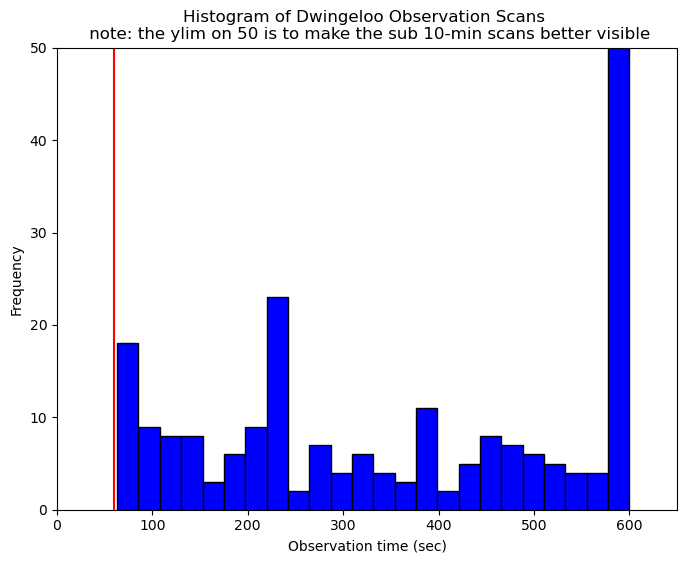

In [19]:
def dwingeloo_histogram(df):
    """
    made with chatGPT
    Generate a histogram of observation scan times from Dwingeloo data.

    This function creates a histogram based on the "Time_per_file_(sec)" column
    of the provided DataFrame. It visualizes the frequency distribution of scan
    durations, adds axis labels, a title, and overlays a vertical red line at 60 seconds. 

    Parameters:
    -----------
    df : pandas.DataFrame
        A DataFrame containing a column named "Time_per_file_(sec)" 
        with the observation scan times in seconds.

    Returns:
    --------
    None
        Displays a histogram plot.
    """
    # Extract the observation times from the DataFrame column
    times_per_obs = df["Time_per_file_(sec)"].values

    # Create the histogram with square-root optimized bin count
    plt.figure(figsize=(8,6))
    plt.hist(times_per_obs, bins='sqrt', color='blue', edgecolor='black')  
    
    # Add labels for the x-axis and y-axis
    plt.xlabel('Observation time (sec)')
    plt.ylabel('Frequency')
    
    # Add a title to the plot
    plt.title('Histogram of Dwingeloo Observation Scans \n note: the ylim on 50 is to make the sub 10-min scans better visible')
    
    # Set the range of the x-axis (time) and y-axis (frequency)
    plt.xlim(0, 650)
    plt.ylim(0, 50)
    
    # Add a vertical red line at 60 seconds for reference
    plt.axvline(60, color='red')
    
    # Display the plot
    plt.show()

dwingeloo_histogram(df)